# 03 · Predict the star rating as a class (1–5)

**Use case.** The same question as 02, but the product team wants class probabilities — *how sure* is the model this is a 1★ review? — to route angry customers to a person before the review goes live.

**Model / lane:** relational GNN — GATv2 (`model_key="gatv2_full"`), 5 classes, text embeddings

**What you will learn**
1. Define the task as **multiclass** classification and pick an architecture (`model_key="gatv2_full"`)
2. Accuracy and macro-F1 on the test split vs the always-5★ baseline (63% of reviews are 5★)
3. The Model tab: confusion matrix, accuracy/F1 per epoch — as images
4. Per-class recall from the confusion matrix
5. The 1★ queue: rank every review by P(1★) and read the top of it

**What this costs.** one GPU training run (a few minutes on `g4dn.2xlarge`; the API reserves the estimate — about 8,700 credits on the Team plan — and refunds the unused minutes, so a 90-second run ends up costing a few hundred), plus 50 credits per on-demand prediction. A re-run that finds the finished model pays only for its predictions.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "rating-classes", kind="data_science")
before = credits_used(ls)

reusing project c40a4efc-7d71-4534-85f1-f80135e71ab5 (amazon-reviews-rating-classes, status=ready)
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


## Define the task, train

The task is one sentence. `train_or_reuse` prints the config Langsat derived (entity table, target, which text columns get embedded), the estimate, then polls the run and reuses a finished model on re-runs. `model_key` picks the architecture; the default is GraphSAGE. GATv2 weighs neighbours (the product's other reviews, the customer's other reviews) with attention.

In [3]:
model = train_or_reuse(p, "Classify each review into its star rating from 1 to 5 using the review text, the summary and the product",
                       task_type="supervised", subtask_type="multiclass_classification", enable_text_embedding=True, model_key="gatv2_full")
metrics = model["metrics"]
show(metrics, keys=("acc", "f1_macro", "precision_macro", "recall_macro"))

reusing model cb1c7b94-613b-413a-9bf7-50342f63a953 (GAT, trained 2026-09-15T09:02:45.456967+00:00)
  acc                    0.665
  f1_macro               0.4655
  recall_macro           0.4516
  precision_macro        0.4991


In [4]:
review = p.table("review").to_pandas()
majority = review["rating"].value_counts(normalize=True).max()
print(f"always-5★ baseline · accuracy {majority:.3f} · macro-F1 {(2*majority)/(majority+1)/5:.3f} (only one class ever right)")
print(f"model (test split)  · accuracy {metrics.get('acc'):.3f} · macro-F1 {metrics.get('f1_macro'):.3f}")

always-5★ baseline · accuracy 0.631 · macro-F1 0.155 (only one class ever right)
model (test split)  · accuracy 0.665 · macro-F1 0.466


## The Model tab, as images

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

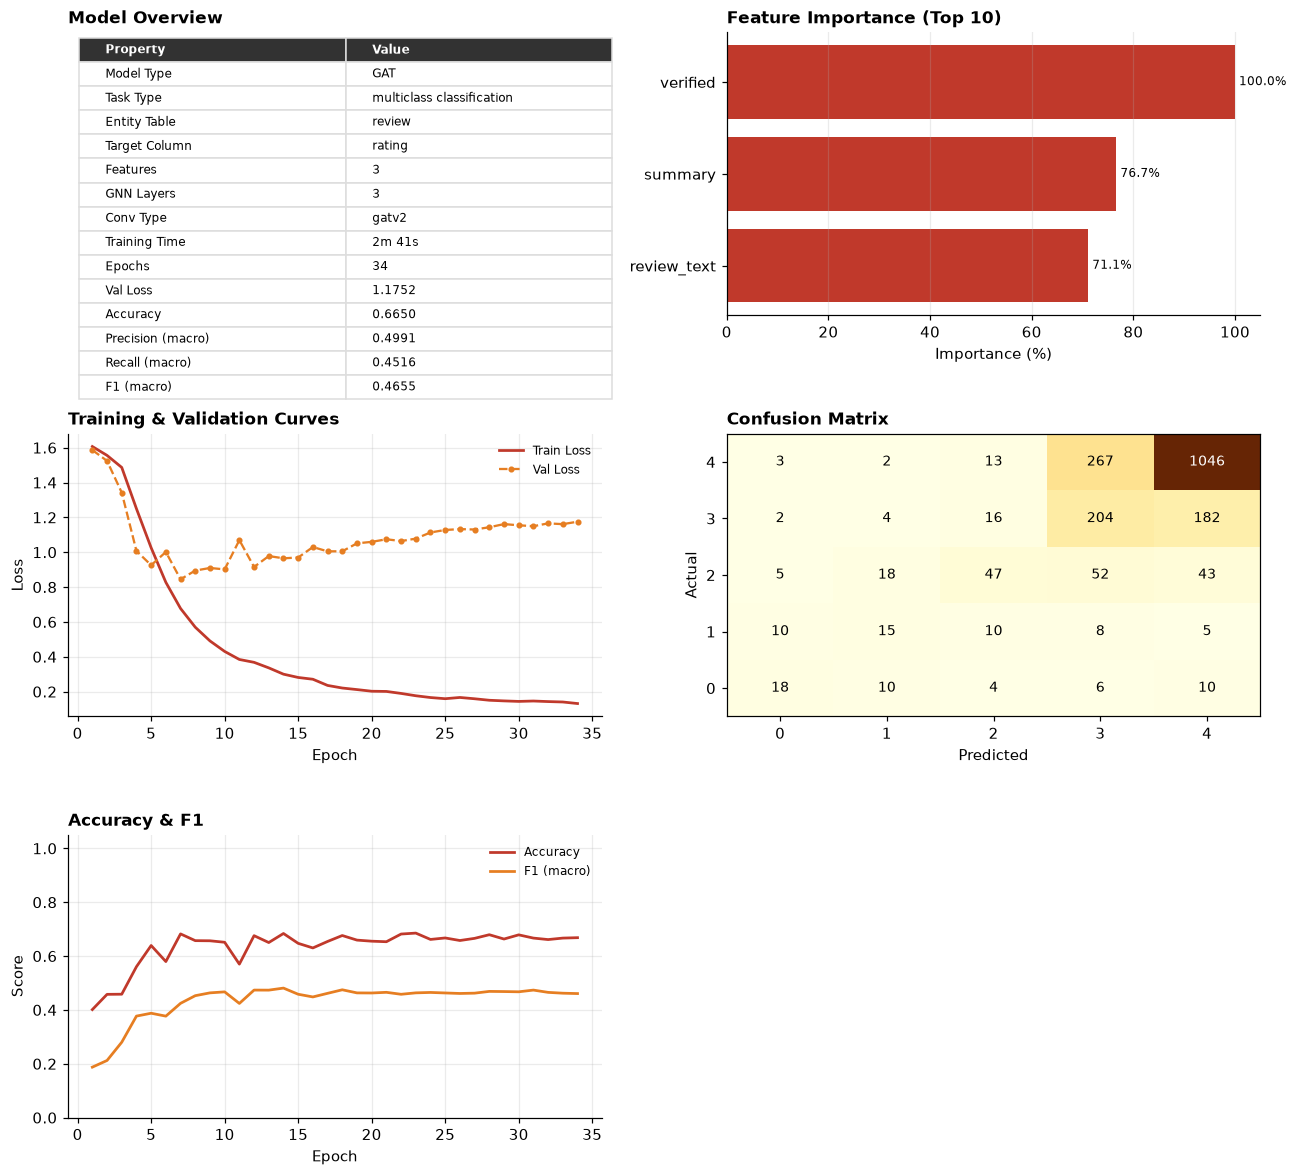

In [5]:
fig(viz.model_dashboard(p, cols=2))

The confusion matrix card carries the counts (the API's `metrics` dict is scalars only). Rows are actual classes, columns predicted — per-class recall is the diagonal over the row sum. Expect the 5★ class to dominate and the 2★/3★ classes to be hardest: they are rare and sit between neighbours.

,pred 0,pred 1,pred 2,pred 3,pred 4
actual 4,3,2,13,267,1046
actual 3,2,4,16,204,182
actual 2,5,18,47,52,43
actual 1,10,15,10,8,5
actual 0,18,10,4,6,10


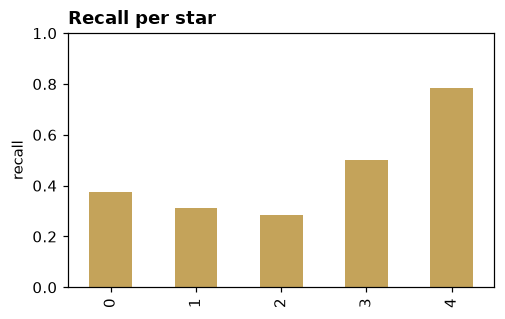

In [6]:
cm_card = viz.model_cards(p)["Confusion Matrix"]
tr = cm_card["plotly"]["data"][0]
cm = pd.DataFrame(tr["z"], index=[f"actual {y}" for y in tr["y"]], columns=[f"pred {x}" for x in tr["x"]])
display(cm)
recall = pd.Series({str(tr["y"][i]): row[list(tr["x"]).index(tr["y"][i])] / max(sum(row), 1) for i, row in enumerate(tr["z"])}).sort_index()
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(5, 3)); recall.plot(kind="bar", ax=ax, color="#c4a35a"); ax.set_ylim(0, 1); ax.set_ylabel("recall")
ax.set_title("Recall per star", loc="left", fontweight="bold"); fig(f)

## The 1★ queue

A multiclass model carries five probabilities per row, so a ranking needs to say which class: `class_index=0` is the first label (1★). That list is the routing queue for the support team — with the text, so a person can act on it.

In [7]:
labels = metrics.get("class_labels") or [1, 2, 3, 4, 5]
top = ls.predict.top(model["model_id"], n=8, class_index=0)             # rank by P(rating == labels[0])
print("ranked by:", top.get("ranked_by"), "· class", labels[0], "★ ·", top.get("total_ranked"), "ranked")
queue = pd.DataFrame([{"review": r["entity_id"], "P(1★)": round(r["score"], 3)} for r in top["ranking"]])
queue = queue.merge(review.reset_index().rename(columns={"index": "review"}), on="review", how="left")
queue[["review", "P(1★)", "rating", "summary"]]

ranked by: class_probability · class 1 ★ · 2000 ranked


,review,P(1★),rating,summary
0,8451,1.000,1,One Star
1,8248,1.000,1,Never ordered this!
2,122,1.000,1,One Star
3,133,1.000,5,irrefutable arguments. The Dems need to quit u...
4,469,1.000,1,Waste of money
5,691,1.000,1,One Star
6,9342,0.999,1,Terrible waste of money
7,570,0.999,1,One Star


prediction: 1 · probabilities: {'1': 1.0, '2': 0.0, '3': 0.0, '4': 0.0, '5': 0.0}


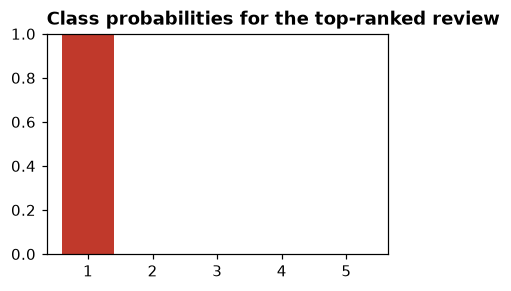

In [8]:
one = ls.predict.predict(model_id=model["model_id"], entity_id=top["ranking"][0]["entity_id"])
probs = one["result"].get("probabilities") or {}
print("prediction:", one["result"]["prediction"], "· probabilities:", {k: round(v, 3) for k, v in probs.items()})
f, ax = plt.subplots(figsize=(4, 2.6)); ax.bar(list(probs), list(probs.values()), color="#c0392b"); ax.set_ylim(0, 1)
ax.set_title("Class probabilities for the top-ranked review", loc="left", fontweight="bold"); fig(f)

In [9]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "03_rating_classification", "task": "multiclass · review.rating (5 classes)", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"accuracy": metrics.get("acc"), "f1_macro": metrics.get("f1_macro"), "recall_1star": round(float(recall.iloc[0]), 4)},
                   "baseline": {"accuracy": round(float(majority), 4), "f1_macro_note": "always-5★"}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [04 · Verified purchase](../04_verified_purchase_binary/) — a binary target, ROC and PR-AUC
- [08 · Predict API & monitoring](../08_predict_api_and_monitoring/) — serving a model from an application